In [13]:
#importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree




In [4]:
#loading the dataset
df = pd.read_csv("syriatel customer churn.csv")


In [5]:
#data inspection
print(df.head())
print(df.info())
print(df['churn'].value_counts())  # target variable


  state  account length  area code phone number international plan  \
0    KS             128        415     382-4657                 no   
1    OH             107        415     371-7191                 no   
2    NJ             137        415     358-1921                 no   
3    OH              84        408     375-9999                yes   
4    OK              75        415     330-6626                yes   

  voice mail plan  number vmail messages  total day minutes  total day calls  \
0             yes                     25              265.1              110   
1             yes                     26              161.6              123   
2              no                      0              243.4              114   
3              no                      0              299.4               71   
4              no                      0              166.7              113   

   total day charge  ...  total eve calls  total eve charge  \
0             45.07  ...           

In [6]:
#defining features and target variables
X = df.drop('churn', axis=1)
y = df['churn']

In [7]:
#splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
#preprocessing pipeline
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Build Models

In [11]:
#logistic regression pipeline
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [12]:
#random forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

In [14]:
#decision tree pipeline
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,       
        min_samples_split=10,
        random_state=42
    ))
])


In [15]:
#train models
logistic_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)




Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['account length', 'area code', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['state', 'phone number', 'international plan', 'voice mail plan'], dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        random

In [18]:
#evaluating models
for name, model in [("Logistic Regression", logistic_pipeline), ("Random Forest", rf_pipeline), ("Decision Tree", dt_pipeline)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:,1]

print("\nDecision Tree Results:")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))




Logistic Regression Results:
              precision    recall  f1-score   support

       False       0.88      0.96      0.92       570
        True       0.53      0.25      0.34        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667

ROC-AUC: 0.8092421776089708
Confusion Matrix:
 [[549  21]
 [ 73  24]]

Random Forest Results:
              precision    recall  f1-score   support

       False       0.90      0.99      0.95       570
        True       0.93      0.38      0.54        97

    accuracy                           0.91       667
   macro avg       0.91      0.69      0.74       667
weighted avg       0.91      0.91      0.89       667

ROC-AUC: 0.8925574244890577
Confusion Matrix:
 [[567   3]
 [ 60  37]]

Decision Tree Results:
              precision    recall  f1-score   support

       False       0.94      0.96      0.95       570
        True       

Hyperparameter Tuning


In [19]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns



In [20]:
#hyperparameter tuning for random forest
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best Parameters:", rf_grid.best_params_)
print("Best ROC-AUC:", rf_grid.best_score_)


Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best ROC-AUC: 0.9120446074393442


In [22]:
#evaluating tuned random forest model
y_pred = rf_grid.predict(X_test)
y_proba = rf_grid.predict_proba(X_test)[:,1]

print("\nTuned Random Forest Results:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))






Tuned Random Forest Results:
              precision    recall  f1-score   support

       False       0.90      0.99      0.94       570
        True       0.89      0.34      0.49        97

    accuracy                           0.90       667
   macro avg       0.90      0.67      0.72       667
weighted avg       0.90      0.90      0.88       667

ROC-AUC: 0.8868330620365348
Confusion Matrix:
 [[566   4]
 [ 64  33]]


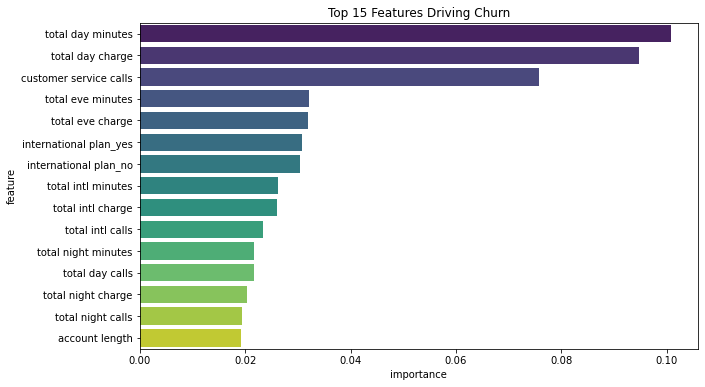

In [28]:
#extracting feature importances
best_model = rf_grid.best_estimator_
clf = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

# Reconstruct feature names: numeric features + one-hot encoded categorical features
numeric_names = list(numeric_features)
categorical_encoder = preprocessor.named_transformers_['cat']
categorical_names = list(categorical_encoder.get_feature_names(categorical_features)) if hasattr(categorical_encoder, 'get_feature_names') else None

if categorical_names:
    feature_names = numeric_names + categorical_names
else:
    # Fallback: just use numeric names and numbered categorical
    n_cat_features = len(categorical_features)
    feature_names = numeric_names + [f'cat_{i}' for i in range(clf.feature_importances_.shape[0] - len(numeric_names))]

importances = clf.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feat_imp, palette="viridis")
plt.title("Top 15 Features Driving Churn")
plt.show()

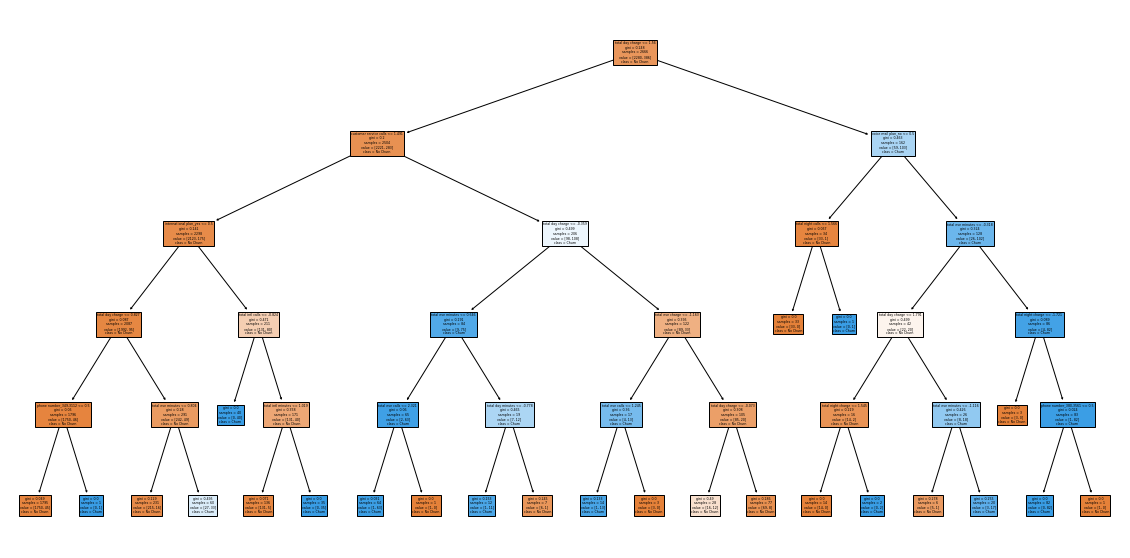

In [29]:
#visualizing the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_pipeline.named_steps['classifier'], filled=True, feature_names=feature_names, class_names=['No Churn', 'Churn'])
plt.show()

Comparing all three models to evaluate perfomance

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [32]:
#function to evaluate model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }




In [36]:
#collecting results
results = []
results.append(evaluate_model("Logistic Regression", logistic_pipeline, X_test, y_test))
results.append(evaluate_model("Random Forest (Tuned)", rf_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model("Decision Tree", dt_pipeline, X_test, y_test))

In [38]:
#combined model performance summary
results_df = pd.DataFrame(results)
print(results_df)


                   Model  Accuracy  Precision    Recall        F1   ROC-AUC
0    Logistic Regression  0.859070   0.533333  0.247423  0.338028  0.809242
1  Random Forest (Tuned)  0.898051   0.891892  0.340206  0.492537  0.886833
2          Decision Tree  0.917541   0.756098  0.639175  0.692737  0.804350
